Dataset shape: X=(500, 2), y=(500,)

Evaluating KNN performance for k from 1 to 30 using 10-fold cross-validation...
  k =  1: Mean Error Rate = 0.0460 (Std Dev = 0.0297)
  k =  2: Mean Error Rate = 0.0540 (Std Dev = 0.0369)
  k =  3: Mean Error Rate = 0.0320 (Std Dev = 0.0223)
  k =  4: Mean Error Rate = 0.0380 (Std Dev = 0.0244)
  k =  5: Mean Error Rate = 0.0420 (Std Dev = 0.0209)
  k =  6: Mean Error Rate = 0.0420 (Std Dev = 0.0209)
  k =  7: Mean Error Rate = 0.0400 (Std Dev = 0.0219)
  k =  8: Mean Error Rate = 0.0400 (Std Dev = 0.0237)
  k =  9: Mean Error Rate = 0.0480 (Std Dev = 0.0271)
  k = 10: Mean Error Rate = 0.0440 (Std Dev = 0.0250)
  k = 11: Mean Error Rate = 0.0460 (Std Dev = 0.0220)
  k = 12: Mean Error Rate = 0.0460 (Std Dev = 0.0220)
  k = 13: Mean Error Rate = 0.0480 (Std Dev = 0.0240)
  k = 14: Mean Error Rate = 0.0480 (Std Dev = 0.0240)
  k = 15: Mean Error Rate = 0.0520 (Std Dev = 0.0223)
  k = 16: Mean Error Rate = 0.0480 (Std Dev = 0.0223)
  k = 17: Mean Erro

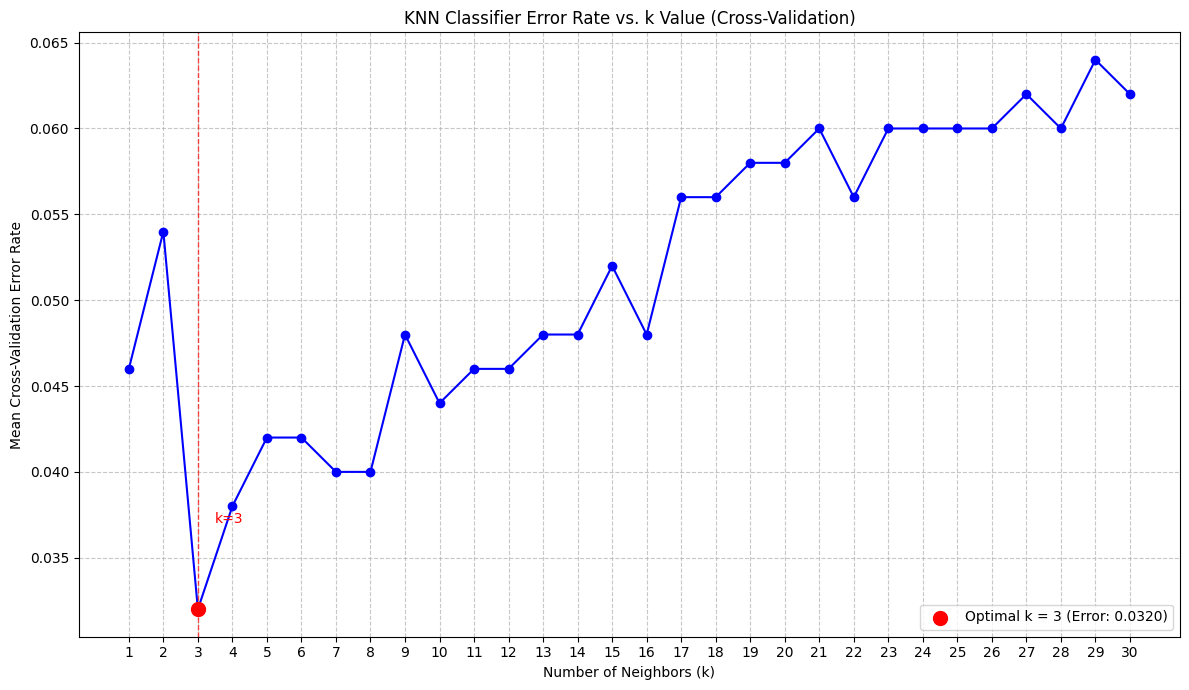


Minimum error rate of 0.0320 achieved at k = 3


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification # Using a synthetic dataset for demonstration
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline # To combine scaling and KNN

# 1. Generate a synthetic dataset
# We'll create a binary classification problem with 2 features
X, y = make_classification(
    n_samples=500,        # Number of samples
    n_features=2,         # Number of features
    n_informative=2,      # Number of informative features
    n_redundant=0,        # Number of redundant features
    n_repeated=0,         # Number of repeated features
    n_classes=2,          # Number of classes
    n_clusters_per_class=1, # Number of clusters per class
    random_state=42       # For reproducibility
)

print(f"Dataset shape: X={X.shape}, y={y.shape}")

# 2. Define a range of k values to test
k_values = list(range(1, 31)) # Test k from 1 to 30

# Store error rates for each k
mean_error_rates = []
std_error_rates = [] # To show variability if needed

# 3. Set up Cross-Validation
# We use StratifiedKFold to ensure class proportions are maintained in each fold
n_splits = 10 # Number of folds for cross-validation
kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

print(f"\nEvaluating KNN performance for k from {k_values[0]} to {k_values[-1]} using {n_splits}-fold cross-validation...")

# 4. Loop through different k values
for k in k_values:
    # Create a pipeline: first scale the data, then apply KNN
    # This ensures scaling is done correctly within each cross-validation fold
    knn_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])

    # Perform cross-validation and get accuracy scores
    scores = cross_val_score(knn_pipeline, X, y, cv=kf, scoring='accuracy', n_jobs=-1) # n_jobs=-1 uses all available CPU cores

    # Calculate mean error rate (1 - accuracy)
    mean_accuracy = np.mean(scores)
    mean_error = 1 - mean_accuracy
    std_error = np.std(scores) # Standard deviation of errors across folds

    mean_error_rates.append(mean_error)
    std_error_rates.append(std_error)

    print(f"  k = {k:2d}: Mean Error Rate = {mean_error:.4f} (Std Dev = {std_error:.4f})")

# 5. Plot the error rate
plt.figure(figsize=(12, 7))
plt.plot(k_values, mean_error_rates, marker='o', linestyle='-', color='blue')

# Optionally, add error bars for standard deviation
# plt.errorbar(k_values, mean_error_rates, yerr=std_error_rates, fmt='o', capsize=5, color='gray', alpha=0.5)

# Find the k with the minimum error rate
min_error_k = k_values[np.argmin(mean_error_rates)]
min_error_value = np.min(mean_error_rates)

# Mark the minimum error point on the plot
plt.scatter(min_error_k, min_error_value, color='red', s=100, zorder=5, label=f'Optimal k = {min_error_k} (Error: {min_error_value:.4f})')
plt.axvline(x=min_error_k, color='red', linestyle='--', linewidth=1, alpha=0.7)
plt.text(min_error_k + 0.5, min_error_value + 0.005, f'k={min_error_k}', color='red', fontsize=10, ha='left')


plt.title('KNN Classifier Error Rate vs. k Value (Cross-Validation)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Cross-Validation Error Rate')
plt.xticks(k_values) # Ensure all k values are shown on x-axis
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nMinimum error rate of {min_error_value:.4f} achieved at k = {min_error_k}")
